# H1 — Random Forest: raw Jaccard similarity vs. node2vec embeddings, across all 9 biological layers

## Purpose
Compares two ways of turning biological-overlap similarity into features for a DDI classifier, for **each of the 9 layers** (`identity_L0/L1/L2`, `go_mf`, `go_bp`, `go_cc`, `pfam`, `pathway_native`, `pathway_inferred`) -- both trained and evaluated on the **exact same rows and train/test split within each layer**:

- **Model A (similarity score):** a Random Forest using only that layer's raw `{layer}_jaccard` scalar for each drug pair.
- **Model B (node2vec embeddings):** a Random Forest using node2vec embeddings of both drugs (from that layer's canonical combined-graph embedding), combined into a pair-level feature vector.

**Task:** predict whether a drug pair is an *adverse* interaction (label = 1) or a *non-interacting* pair (label = 0). Same methodology as [`structural_sim_embedding_comparison.ipynb`](../h3_structural_similarity/structural_sim_embedding_comparison.ipynb) (H3) and [`atc_sim_embedding_comparison.ipynb`](../h2_pharmacological_similarity/atc_sim_embedding_comparison.ipynb) (H2), minus the raw-fingerprint third model -- biological overlap, like ATC, doesn't have an equivalent fixed-size raw numeric representation the way Morgan fingerprints do. Unlike H2/H3, this comparison is repeated **once per layer** since H1 has 9 separate similarity graphs instead of one.

## Important: why this notebook loads the combined-graph embeddings, not the per-population ones

`node2vec_embedding.ipynb` saves **three** embedding tables per layer: `adverse_{layer}_node2vec.parquet` and `non_interacting_{layer}_node2vec.parquet` (one per population, for diagnosing each graph's topology in isolation) and `combined_{layer}_node2vec.parquet` (one shared model trained on the union of both populations). Model B here uses **only the combined ones**, and it's worth being explicit about why:

The two per-population embedding tables come from **two separately-trained node2vec models**. Skip-gram embeddings have no canonical coordinate system: each training run's vector space is its own arbitrary rotation/scale, only meaningful relative to itself. If we built a classifier where every label=1 row's embeddings came from model_adverse and every label=0 row's embeddings came from model_non_interacting, the classifier could trivially separate the classes by detecting *which arbitrary vector space* a pair's embeddings came from -- **not** by learning genuine biological signal. Worse, at prediction time for a genuinely new pair, there'd be no way to know *which* graph's embedding to use without already knowing the label you're trying to predict.

**The fix (already applied in `node2vec_embedding.ipynb` Section 7):** train **one** node2vec model per layer on a **single combined graph** built from the union of both pair populations, with label-agnostic edge weights (the raw Jaccard score). This notebook just loads those results rather than rebuilding them.

## Pipeline
1. Load & label the biological-overlap pair data (adverse = 1, non_interacting = 0).
2. Load all 9 canonical combined-graph node2vec embeddings (built in `node2vec_embedding.ipynb`).
3. For each layer: sample pairs, build one shared train/test split, train Model A (raw Jaccard score) and Model B (node2vec embeddings), and evaluate both with the same metrics.
4. Compare all 9 layers side by side.
5. Save all 18 models (9 layers x 2 models).
6. Conclusions & recommendations.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)

sns.set_theme(style="whitegrid")

H1_DIR = Path(r"C:\Users\ashto\ddi-prediction\notebooks\h1_biological_overlap")
EMBEDDING_DIR = H1_DIR / "embeddings"
MODEL_OUTPUT_DIR = H1_DIR / "models" / "bio_rf_comparison"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Configuration

`MAX_PAIRS_PER_CLASS` caps how many rows are sampled per label before training -- both classes have far more pairs than needed for a Random Forest to converge, and using equal counts per class gives a balanced 50/50 training set. Set it to `None` to use every available row (slower, and repeated 9 times here so the cost multiplies).

In [2]:
# --- The 9 biological layers, in the same order used throughout H1 ---
LAYERS = [
    "identity_L0", "identity_L1", "identity_L2",
    "go_mf", "go_bp", "go_cc",
    "pfam", "pathway_native", "pathway_inferred",
]

# --- Data sources ---
ADVERSE_PATH = H1_DIR / "adverse_biological_overlap_extended.parquet"
NON_INTERACTING_PATH = H1_DIR / "non_interacting_biological_overlap_extended.parquet"

# --- Pair-embedding combination strategy ---
# "hadamard" -> elementwise product of the two drugs' embeddings (symmetric, the node2vec paper's
#               best-performing default for link-prediction-style tasks)
# "average"  -> elementwise mean of the two embeddings (symmetric)
# "abs_diff" -> elementwise |a - b| (symmetric)
# "concat"   -> [emb_a | emb_b] (NOT symmetric -- included only for comparison)
EMBEDDING_FEATURE_MODE = "hadamard"

# --- Sampling / split (shared identically by both models, per layer) ---
MAX_PAIRS_PER_CLASS = 25_000  # set to None to use all available pairs
TEST_SIZE = 0.2
RANDOM_STATE = 42

# --- Random Forest (same config for both models and every layer, so any performance gap is due to features, not model config) ---
RF_PARAMS = dict(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

## 1. Load & label pair data

`*_biological_overlap_extended.parquet` has one row per drug pair with `drug1_id`, `drug2_id`, and a `{layer}_jaccard` column for each of the 9 layers -- so, unlike H2/H3, a single pair of files covers every layer.

In [3]:
adverse_df = pd.read_parquet(ADVERSE_PATH)
non_interacting_df = pd.read_parquet(NON_INTERACTING_PATH)

adverse_df["label"] = 1
non_interacting_df["label"] = 0

pairs_df = pd.concat([adverse_df, non_interacting_df], ignore_index=True)

print(f"Adverse pairs:         {len(adverse_df):,}")
print(f"Non-interacting pairs: {len(non_interacting_df):,}")
print(f"Total pairs:           {len(pairs_df):,}")
pairs_df["label"].value_counts().rename({1: "adverse", 0: "non_interacting"})

Adverse pairs:         471,895
Non-interacting pairs: 161,098
Total pairs:           632,993


label
adverse            471895
non_interacting    161098
Name: count, dtype: int64

## 2. Load the 9 canonical combined-graph embeddings

Built once in [`node2vec_embedding.ipynb`](./node2vec_embedding.ipynb) (Section 7) -- one node2vec model per layer, each trained on the union of both pair populations, so the embedding space carries no information about the label. This notebook only *loads* them rather than rebuilding them, so it stays in sync with the diagnostics notebook instead of duplicating that training run.

In [4]:
combined_embeddings = {}
for layer in LAYERS:
    emb = pd.read_parquet(EMBEDDING_DIR / f"combined_{layer}_node2vec.parquet")
    combined_embeddings[layer] = emb
    print(f"{layer:<18}: loaded embeddings {emb.shape}")

identity_L0       : loaded embeddings (1893, 64)
identity_L1       : loaded embeddings (1893, 64)
identity_L2       : loaded embeddings (1893, 64)
go_mf             : loaded embeddings (1893, 64)
go_bp             : loaded embeddings (1893, 64)
go_cc             : loaded embeddings (1893, 64)
pfam              : loaded embeddings (1893, 64)
pathway_native    : loaded embeddings (1893, 64)
pathway_inferred  : loaded embeddings (1893, 64)


## 3. Train & evaluate both models, once per layer

For each layer: drop pairs where either drug has no embedding in that layer's combined graph, sample `MAX_PAIRS_PER_CLASS` pairs per label, build one shared train/test split, then train and evaluate Model A (raw `{layer}_jaccard` scalar) and Model B (node2vec embeddings) on identical rows -- so any performance difference within a layer reflects the features, not a difference in data.

In [5]:
def build_pair_embedding_features(df, embeddings, mode=EMBEDDING_FEATURE_MODE):
    """Combine two drugs' node2vec embeddings into one pair-level feature vector per row."""
    emb_a = embeddings.loc[df["drug1_id"]].to_numpy()
    emb_b = embeddings.loc[df["drug2_id"]].to_numpy()

    if mode == "hadamard":
        return emb_a * emb_b
    if mode == "average":
        return (emb_a + emb_b) / 2
    if mode == "abs_diff":
        return np.abs(emb_a - emb_b)
    if mode == "concat":
        return np.hstack([emb_a, emb_b])
    raise ValueError(f"Unknown EMBEDDING_FEATURE_MODE: {mode!r}")


def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pr_auc": average_precision_score(y_test, y_proba),
    }
    return metrics


layer_models = {}
layer_results = []

for layer in LAYERS:
    t_layer = time.time()
    emb = combined_embeddings[layer]
    embedded_ids = set(emb.index)

    layer_pairs = pairs_df[pairs_df["drug1_id"].isin(embedded_ids) & pairs_df["drug2_id"].isin(embedded_ids)].reset_index(drop=True)

    if MAX_PAIRS_PER_CLASS is not None:
        parts = [
            group.sample(n=min(len(group), MAX_PAIRS_PER_CLASS), random_state=RANDOM_STATE)
            for _, group in layer_pairs.groupby("label")
        ]
        sampled_df = pd.concat(parts, ignore_index=True)
    else:
        sampled_df = layer_pairs
    sampled_df = sampled_df.reset_index(drop=True)

    train_df, test_df = train_test_split(
        sampled_df, test_size=TEST_SIZE, stratify=sampled_df["label"], random_state=RANDOM_STATE
    )
    y_train = train_df["label"].to_numpy()
    y_test = test_df["label"].to_numpy()

    # Model A -- raw Jaccard similarity score
    X_train_a = train_df[[f"{layer}_jaccard"]].to_numpy()
    X_test_a = test_df[[f"{layer}_jaccard"]].to_numpy()
    model_a = RandomForestClassifier(**RF_PARAMS)
    model_a.fit(X_train_a, y_train)

    # Model B -- node2vec embedding pair-features
    X_train_b = build_pair_embedding_features(train_df, emb)
    X_test_b = build_pair_embedding_features(test_df, emb)
    model_b = RandomForestClassifier(**RF_PARAMS)
    model_b.fit(X_train_b, y_train)

    metrics_a = evaluate_model(model_a, X_test_a, y_test, "similarity_score")
    metrics_b = evaluate_model(model_b, X_test_b, y_test, "node2vec_embeddings")
    for metrics in (metrics_a, metrics_b):
        metrics["layer"] = layer
        metrics["n_train"] = len(train_df)
        metrics["n_test"] = len(test_df)
        layer_results.append(metrics)

    layer_models[layer] = {"model_a": model_a, "model_b": model_b}
    print(f"{layer:<18}: n_train={len(train_df):,}, n_test={len(test_df):,} "
          f"-- roc_auc similarity_score={metrics_a['roc_auc']:.3f}, node2vec_embeddings={metrics_b['roc_auc']:.3f} "
          f"({time.time() - t_layer:.1f}s)")

results_df = pd.DataFrame(layer_results).set_index(["layer", "model"]).round(4)
results_df

identity_L0       : n_train=40,000, n_test=10,000 -- roc_auc similarity_score=0.525, node2vec_embeddings=0.771 (12.0s)
identity_L1       : n_train=40,000, n_test=10,000 -- roc_auc similarity_score=0.670, node2vec_embeddings=0.770 (11.8s)
identity_L2       : n_train=40,000, n_test=10,000 -- roc_auc similarity_score=0.673, node2vec_embeddings=0.764 (13.5s)
go_mf             : n_train=40,000, n_test=10,000 -- roc_auc similarity_score=0.559, node2vec_embeddings=0.769 (12.3s)
go_bp             : n_train=40,000, n_test=10,000 -- roc_auc similarity_score=0.571, node2vec_embeddings=0.757 (12.0s)
go_cc             : n_train=40,000, n_test=10,000 -- roc_auc similarity_score=0.592, node2vec_embeddings=0.758 (12.7s)
pfam              : n_train=40,000, n_test=10,000 -- roc_auc similarity_score=0.551, node2vec_embeddings=0.755 (11.8s)
pathway_native    : n_train=40,000, n_test=10,000 -- roc_auc similarity_score=0.514, node2vec_embeddings=0.645 (13.5s)
pathway_inferred  : n_train=40,000, n_test=10,00

accuracy  precision  recall      f1  \
layer            model                                                      
identity_L0      similarity_score       0.5254     0.8735  0.0594  0.1112   
                 node2vec_embeddings    0.6965     0.6995  0.6890  0.6942   
identity_L1      similarity_score       0.6619     0.7372  0.5032  0.5981   
                 node2vec_embeddings    0.6995     0.6909  0.7220  0.7061   
identity_L2      similarity_score       0.6617     0.7248  0.5214  0.6065   
                 node2vec_embeddings    0.6984     0.6928  0.7128  0.7027   
go_mf            similarity_score       0.5560     0.6216  0.2862  0.3919   
                 node2vec_embeddings    0.7066     0.7258  0.6640  0.6935   
go_bp            similarity_score       0.5700     0.6391  0.3216  0.4279   
                 node2vec_embeddings    0.6904     0.6995  0.6676  0.6832   
go_cc            similarity_score       0.5662     0.5711  0.5320  0.5508   
                 node2vec_embeddings    0.6921     0.7048  0.6612  0.6823   
pfam             similarity_score       0.5502     0.6902  0.1822  0.2883   
                 node2vec_embeddings    0.6877     0.6849  0.6952  0.6900   
pathway_native   similarity_score       0.5146     0.8202  0.0374  0.0715   
                 node2vec_embeddings    0.6002     0.6397  0.4588  0.5344   
pathway_inferred similarity_score       0.5848     0.6076  0.4790  0.5357   
                 node2vec_embeddings    0.6751     0.6818  0.6568  0.6690   

                                      roc_auc  pr_auc  n_train  n_test  
layer            model                                                  
identity_L0      similarity_score      0.5253  0.5216    40000   10000  
                 node2vec_embeddings   0.7709  0.7708    40000   10000  
identity_L1      similarity_score      0.6698  0.6528    40000   10000  
                 node2vec_embeddings   0.7703  0.7680    40000   10000  
identity_L2      similarity_score      0.6728  0.6589    40000   10000  
                 node2vec_embeddings   0.7642  0.7562    40000   10000  
go_mf            similarity_score      0.5591  0.5578    40000   10000  
                 node2vec_embeddings   0.7691  0.7690    40000   10000  
go_bp            similarity_score      0.5708  0.5708    40000   10000  
                 node2vec_embeddings   0.7572  0.7618    40000   10000  
go_cc            similarity_score      0.5922  0.5851    40000   10000  
                 node2vec_embeddings   0.7580  0.7575    40000   10000  
pfam             similarity_score      0.5512  0.5437    40000   10000  
                 node2vec_embeddings   0.7550  0.7479    40000   10000  
pathway_native   similarity_score      0.5137  0.5134    40000   10000  
                 node2vec_embeddings   0.6453  0.6739    40000   10000  
pathway_inferred similarity_score      0.5890  0.5841    40000   10000  
                 node2vec_embeddings   0.7363  0.7443    40000   10000

## 4. Compare all 9 layers side by side

In [6]:
comparison_df = results_df["roc_auc"].unstack("model").loc[LAYERS]
comparison_df["gap"] = comparison_df["node2vec_embeddings"] - comparison_df["similarity_score"]
comparison_df = comparison_df.sort_values("gap", ascending=False)
comparison_df

model,node2vec_embeddings,similarity_score,gap
layer,,,
identity_L0,0.7709,0.5253,0.2456
go_mf,0.7691,0.5591,0.2100
pfam,0.7550,0.5512,0.2038
go_bp,0.7572,0.5708,0.1864
go_cc,0.7580,0.5922,0.1658
pathway_inferred,0.7363,0.5890,0.1473
pathway_native,0.6453,0.5137,0.1316
identity_L1,0.7703,0.6698,0.1005
identity_L2,0.7642,0.6728,0.0914


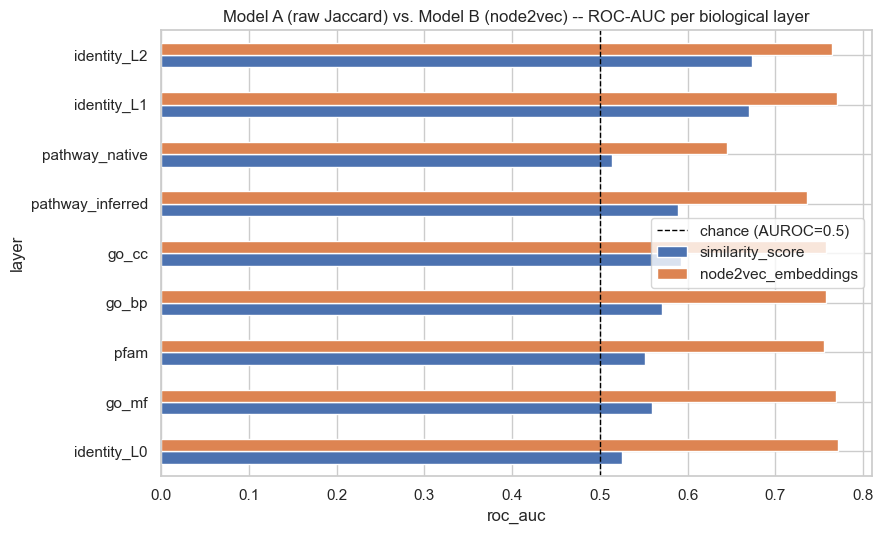

In [7]:
fig, ax = plt.subplots(figsize=(9, 5.5))
comparison_df[["similarity_score", "node2vec_embeddings"]].plot(kind="barh", ax=ax)
ax.axvline(0.5, color="black", linestyle="--", linewidth=1, label="chance (AUROC=0.5)")
ax.set_xlabel("roc_auc")
ax.set_title("Model A (raw Jaccard) vs. Model B (node2vec) -- ROC-AUC per biological layer")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Save models

Both models for every layer are saved to `models/bio_rf_comparison/`, plus one combined `results.csv` covering all 9 layers x 2 models.

In [8]:
for layer, models in layer_models.items():
    joblib.dump(models["model_a"], MODEL_OUTPUT_DIR / f"{layer}_model_a_similarity_score.joblib")
    joblib.dump(models["model_b"], MODEL_OUTPUT_DIR / f"{layer}_model_b_node2vec_embeddings.joblib")

results_df.to_csv(MODEL_OUTPUT_DIR / "results.csv")
print(f"Saved {len(layer_models) * 2} models and results.csv to {MODEL_OUTPUT_DIR}")

Saved 18 models and results.csv to C:\Users\ashto\ddi-prediction\notebooks\h1_biological_overlap\models\bio_rf_comparison


## Conclusions & recommendations (from the executed run)

### Conclusions

1. **Every layer's Model A and Model B were trained/tested on the same 40,000/10,000 rows within that layer** (25,000 pairs sampled per class), so each row below is a genuine apples-to-apples comparison, though the comparison is only within-layer, not across layers (different layers keep different pairs after filtering to embedded drugs):

   | layer | similarity_score (roc_auc) | node2vec_embeddings (roc_auc) | gap |
   |---|---|---|---|
   | identity_L0 | 0.525 | 0.771 | **+0.246** |
   | go_mf | 0.559 | 0.769 | +0.210 |
   | pfam | 0.551 | 0.755 | +0.204 |
   | go_bp | 0.571 | 0.757 | +0.186 |
   | go_cc | 0.592 | 0.758 | +0.166 |
   | pathway_inferred | 0.589 | 0.736 | +0.147 |
   | pathway_native | 0.514 | 0.645 | +0.132 |
   | identity_L1 | 0.670 | 0.770 | +0.100 |
   | identity_L2 | 0.673 | 0.764 | +0.091 |

2. **node2vec embeddings beat the raw Jaccard score in all 9 layers, with no exceptions.** This is the strongest, most consistent finding across H1/H2/H3: a single similarity scalar is a lossy compression of the underlying graph, and node2vec's random-walk training recovers multi-hop neighborhood structure the scalar can't represent at all -- regardless of which biological facet (target identity, GO term, Pfam domain, pathway) the layer captures.
3. **The size of the embedding advantage tracks how weak the raw scalar already was, not how strong the embedding is.** `node2vec_embeddings` roc_auc clusters tightly in a **0.65-0.77** band across all 9 layers (a much narrower spread than Model A's **0.51-0.67**), while the *gap* varies far more (0.09 to 0.25) -- driven almost entirely by how uninformative Model A was for that layer. `identity_L0` and `pathway_native`/`pathway_inferred`/`pfam`/`go_*` all start from a near-chance raw scalar (0.51-0.59) and jump to a respectable ~0.65-0.77 with embeddings; `identity_L1`/`identity_L2` already had a moderately useful raw scalar (0.67) and gain comparatively less.
4. **`pathway_native` remains the weakest layer even after embedding** (0.645 roc_auc, well below every other layer's 0.74-0.77), consistent with `network_generation.ipynb`'s finding that it's the sparsest layer (81% isolate rate in the per-population graphs) -- there's a real information ceiling here that better features can't fully overcome, only partially recover.
5. **This matches H2's finding (ATC: scalar 0.522 -> embedding 0.799, +0.277) more than H3's (structural: scalar 0.554 -> embedding 0.760, +0.207, and beaten by raw fingerprint bits at 0.837).** Like ATC, biological-overlap layers only have a Jaccard-overlap scalar as their "raw" representation (no fixed-size numeric vector equivalent to fingerprint bits exists for target/GO/pathway sets), so -- as with H2 -- node2vec is likely close to the practical ceiling for these feature types rather than an intermediate step between a scalar and a richer raw representation.

### Recommendations

1. **For every one of the 9 biological layers, prefer the node2vec embedding (`combined_{layer}_node2vec.parquet`) over the raw Jaccard score** in any downstream classifier -- the raw scalar underperforms by a wide, consistent margin across the board.
2. **Prioritize `identity_L0`, `identity_L1`, `identity_L2`, and `go_mf`** as the strongest individual embedding layers (all >=0.76 roc_auc); `go_bp`/`go_cc`/`pfam`/`pathway_inferred` form a close second tier (0.74-0.76). Treat `pathway_native` as the weakest and consider dropping it or re-tuning its sparsification (per `network_generation.ipynb`'s existing recommendation) before including it in a final feature table.
3. Since H1 has 9 layers to potentially combine, the eventual final feature table should test **concatenating multiple layers' embeddings** (not just picking the single best layer) alongside the H2/H3 embeddings -- per H3's outstanding recommendation, this is the natural next comparison once single-layer performance is established here.
4. Consider trying `EMBEDDING_FEATURE_MODE = "average"` or `"abs_diff"` as a follow-up ablation, since only `"hadamard"` was tested here (same outstanding recommendation as H2/H3).